## 1. Load and Preprocess the MNIST Dataset

In [ ]:
#23070521113, Vedant Rajekar
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28), (60000,)
Test data shape: (10000, 28, 28), (10000,)


### Visualize some training images

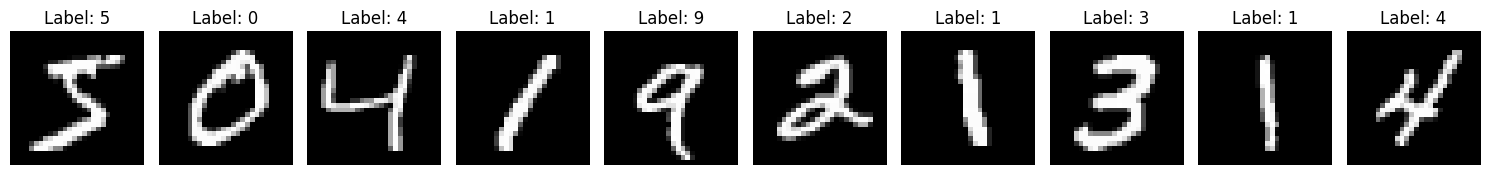

In [ ]:
fig, axes = plt.subplots(ncols=10, sharex=False, sharey=False, figsize=(15, 5))
for i in range(10):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Normalize and Reshape the Data

In [ ]:
# Reshape data to add a channel dimension (28x28x1 for grayscale images)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Convert to float32 and normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Normalized and reshaped training data shape: {X_train.shape}, {y_train.shape}")
print(f"Normalized and reshaped test data shape: {X_test.shape}, {y_test.shape}")

Normalized and reshaped training data shape: (60000, 28, 28, 1), (60000, 10)
Normalized and reshaped test data shape: (10000, 28, 28, 1), (10000, 10)


## 2. Build the CNN Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train and Evaluate the Model

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - accuracy: 0.9302 - loss: 0.2402 - val_accuracy: 0.9768 - val_loss: 0.0813
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.9810 - loss: 0.0622 - val_accuracy: 0.9822 - val_loss: 0.0593
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9867 - loss: 0.0431 - val_accuracy: 0.9859 - val_loss: 0.0498
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9899 - loss: 0.0320 - val_accuracy: 0.9861 - val_loss: 0.0466
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.9918 - loss: 0.0257 - val_accuracy: 0.9884 - val_loss: 0.0396
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9934 - loss: 0.0201 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9943 - loss: 0.0173 - val_accuracy: 0.9870 - val_loss: 0.0463
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9960 - loss: 0

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9915 - loss: 0.0294
Test Loss: 0.0294
Test Accuracy: 0.9915


### Plot Training History

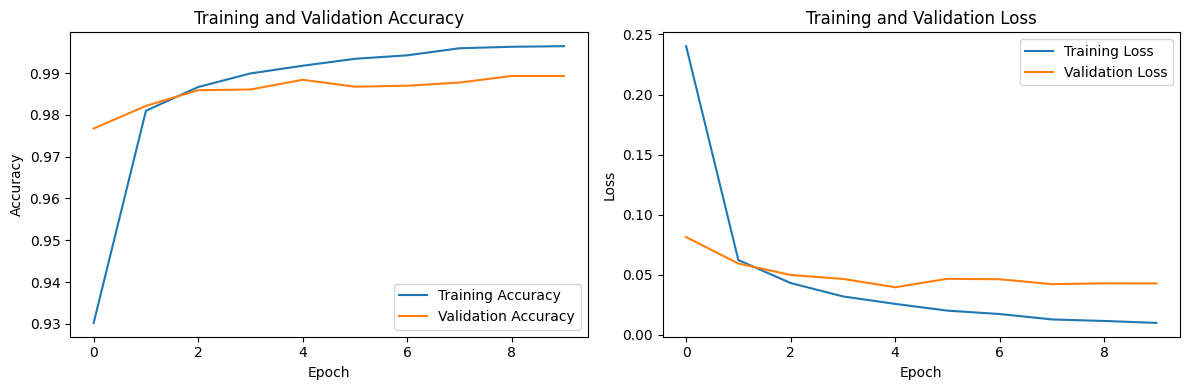

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Display Prediction Results

In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


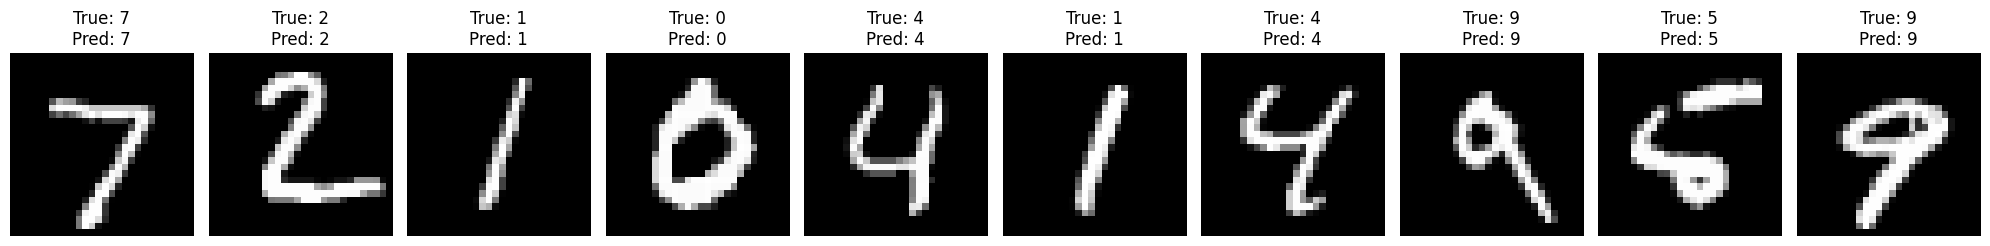

In [ ]:
fig, axes = plt.subplots(ncols=10, sharex=False, sharey=False, figsize=(20, 4))
for i in range(10):
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"True: {y_test_classes[i]}\nPred: {predicted_classes[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Display Misclassified Examples

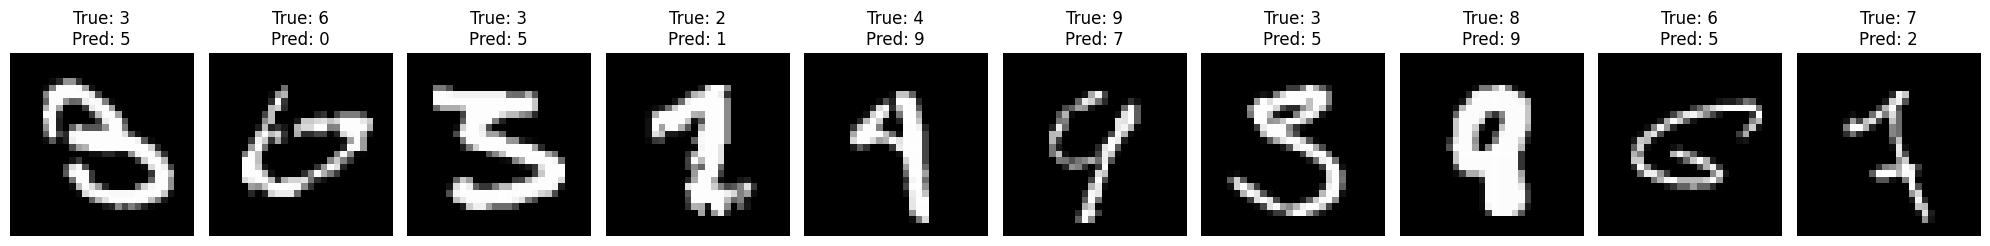

In [ ]:
misclassified_idx = np.where(predicted_classes != y_test_classes)[0]

if len(misclassified_idx) > 0:
    # Display up to 10 misclassified images
    num_to_display = min(len(misclassified_idx), 10)
    fig, axes = plt.subplots(ncols=num_to_display, sharex=False, sharey=False, figsize=(20, 4))

    if num_to_display == 1:
        idx = misclassified_idx[0]
        axes.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        axes.set_title(f"True: {y_test_classes[idx]}\nPred: {predicted_classes[idx]}")
        axes.axis('off')
    else:
        for i in range(num_to_display):
            idx = misclassified_idx[i]
            axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
            axes[i].set_title(f"True: {y_test_classes[idx]}\nPred: {predicted_classes[idx]}")
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples found in the test set (which is unlikely with typical models). ")
    print("The model might be performing exceptionally well or the dataset is too small.")